In [1]:
import numpy as np
import pandas as pd
import scipy

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import LabelEncoder


from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from sklearn.decomposition import PCA

import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

import optuna
from sklearn.metrics import silhouette_score
from pylab import bone, pcolor, colorbar, plot, show
from minisom import MiniSom

In [2]:
data=pd.read_excel(r"C:\Users\user\Downloads\Clustering_marketing_campaign.xlsx")
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,0,0,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,0,0,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,8,2,5,7,0,0,0,1,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,1,0,0,0,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,0,0,0,0


In [3]:
pd.set_option('display.max_columns',None)

In [4]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0


In [5]:
data.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,2012-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
dtype: int64

In [7]:
data.drop('ID',axis=1,inplace=True)

In [8]:
data['Dt_Customer']=pd.to_datetime(data['Dt_Customer'])
data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0


In [9]:
data['year_Dt'] = data['Dt_Customer'].dt.year
data['month_Dt'] = data['Dt_Customer'].dt.month
data['day_Dt']=data['Dt_Customer'].dt.day
data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,2012,9,4
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,2014,3,8
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,2013,8,21
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,2014,2,10
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,2014,1,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,2013,6,13
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,2014,6,10
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,2014,1,25
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,2014,1,24


In [10]:
data.drop('Dt_Customer',axis=1,inplace=True)

In [11]:
for i in data.columns:
    if data[i].dtype=='object':
        labelencoder=LabelEncoder()
        data[i] = labelencoder.fit_transform(data[i])
data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt
0,1957,2,4,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,2012,9,4
1,1954,2,4,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,2014,3,8
2,1965,2,5,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,2013,8,21
3,1984,2,5,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,2014,2,10
4,1981,4,3,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,2014,1,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,2,3,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,2013,6,13
2236,1946,4,5,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,2014,6,10
2237,1981,2,2,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,2014,1,25
2238,1956,3,5,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,2014,1,24


In [12]:
data['Income']=data['Income'].fillna(data['Income'].mode()[0])

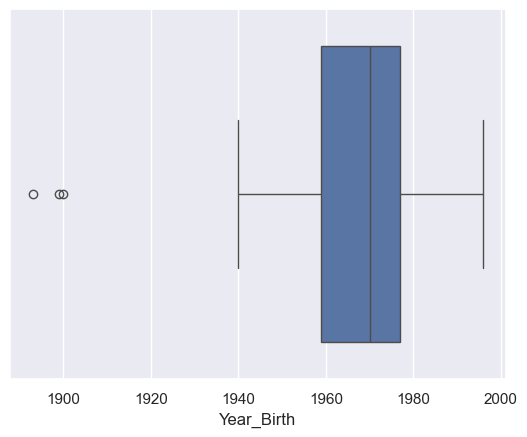

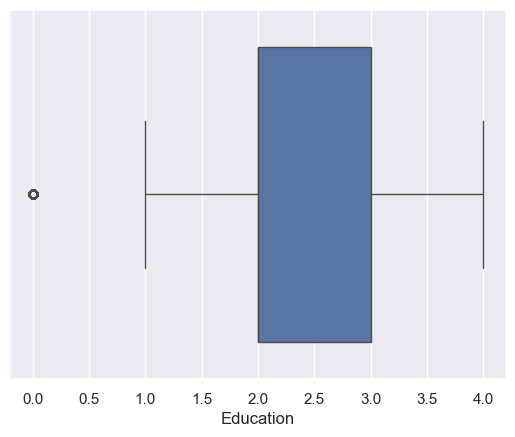

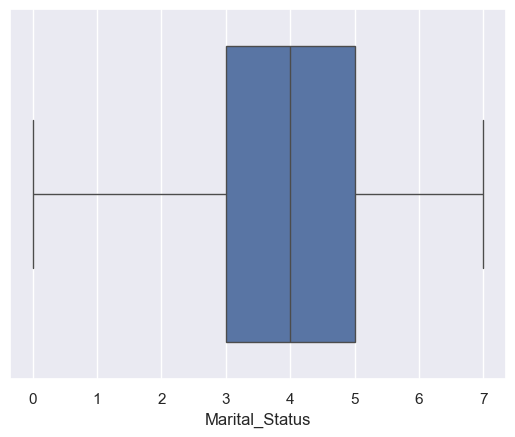

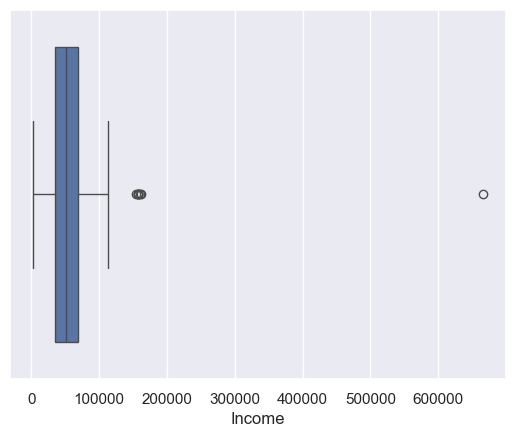

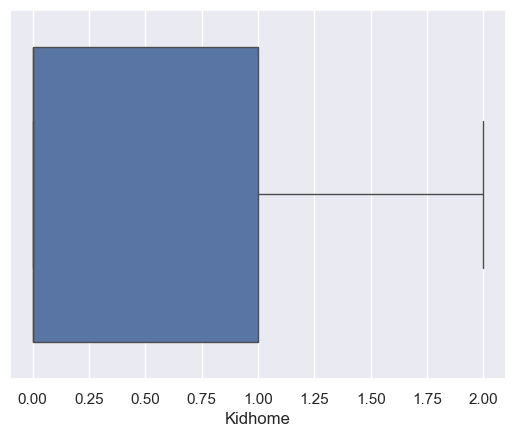

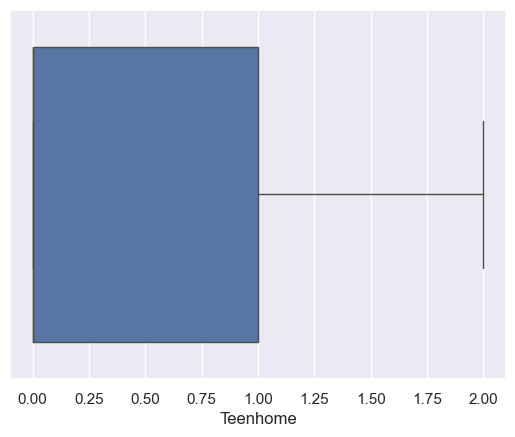

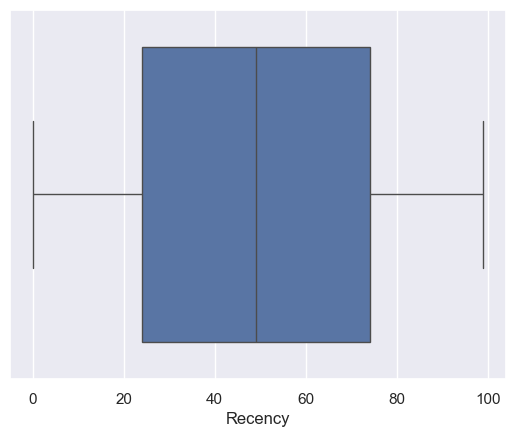

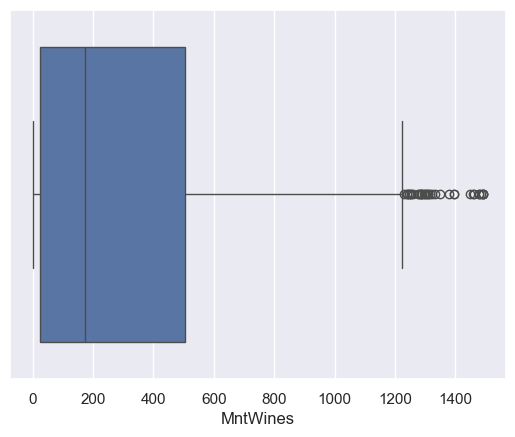

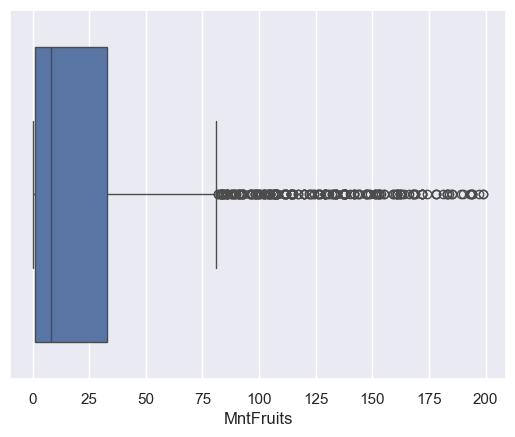

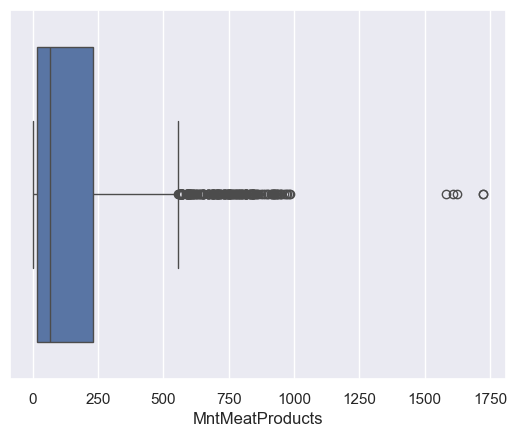

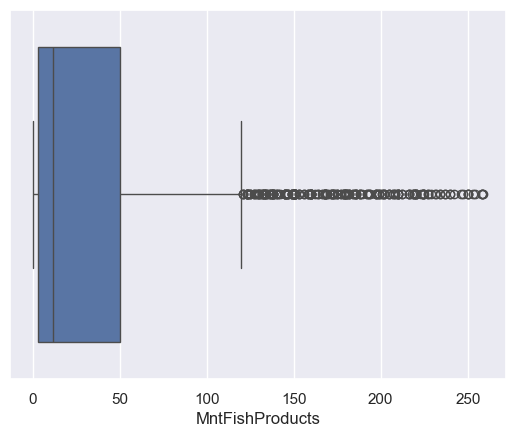

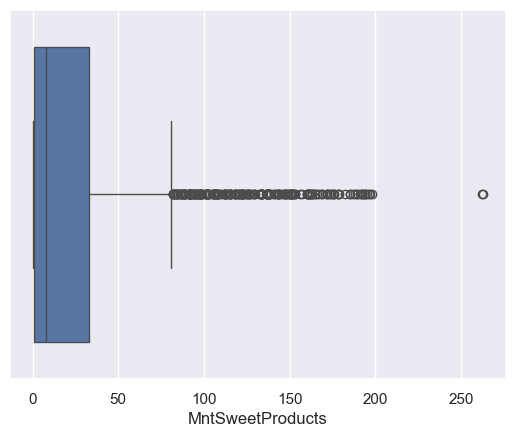

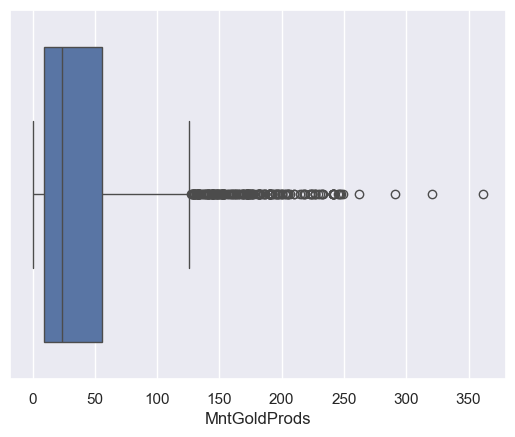

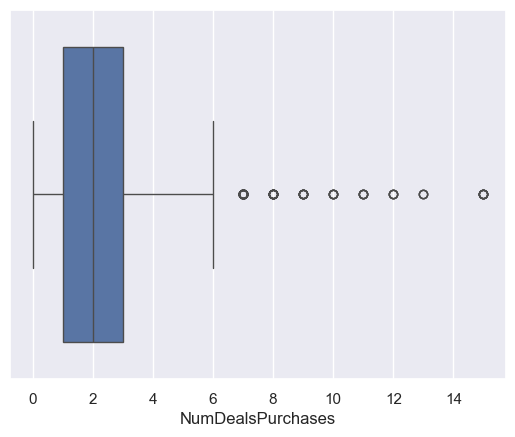

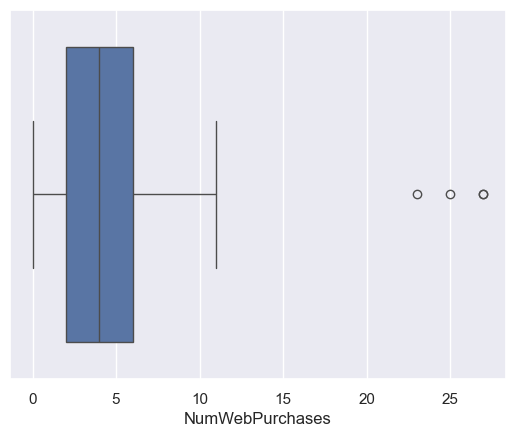

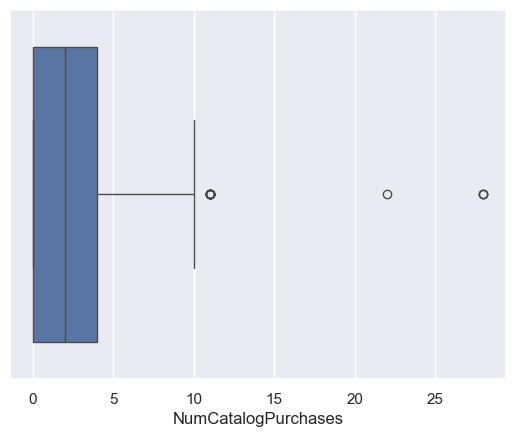

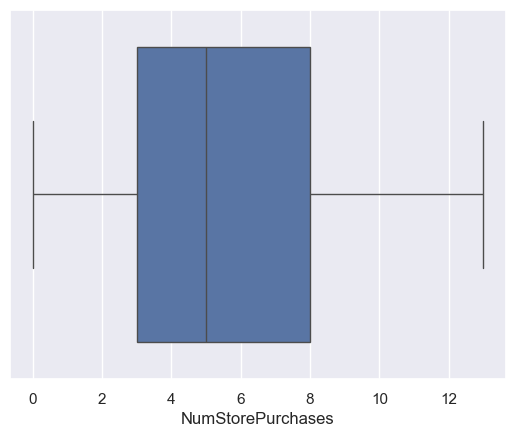

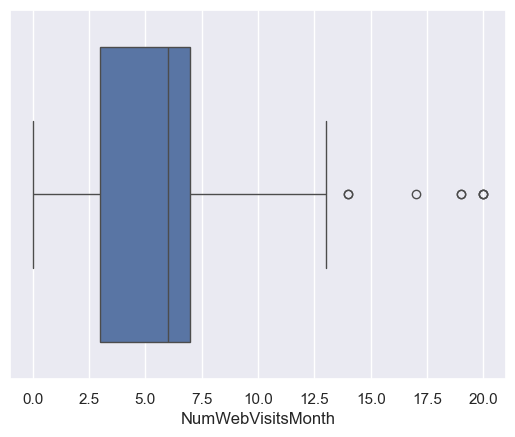

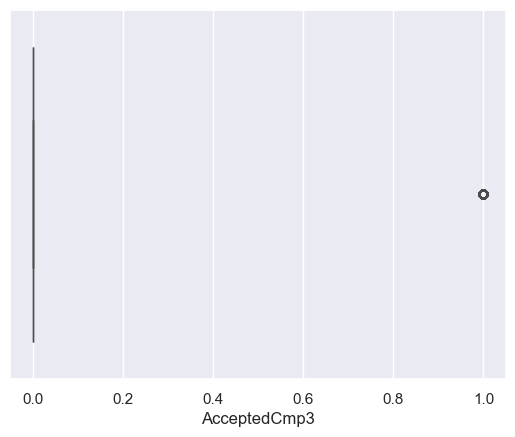

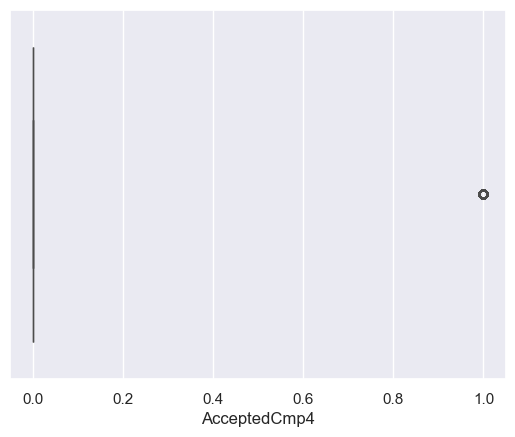

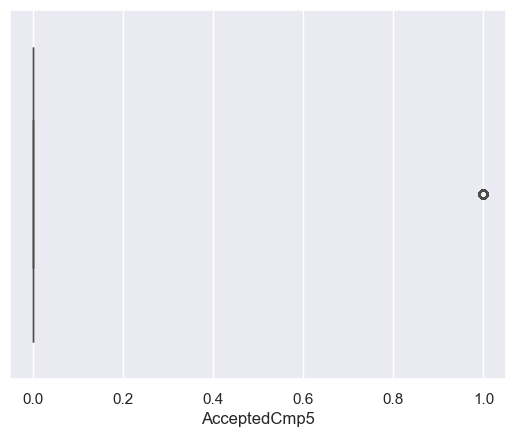

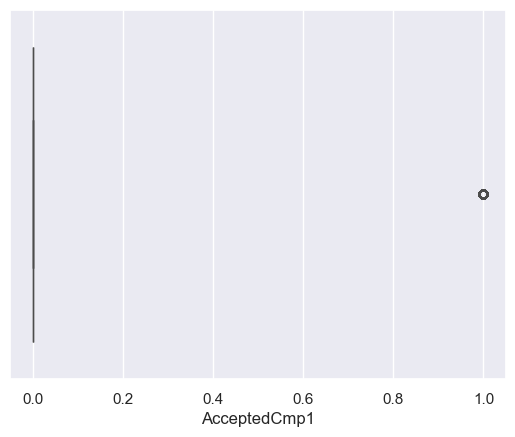

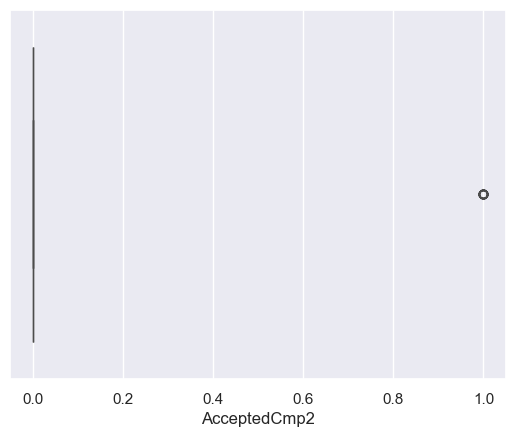

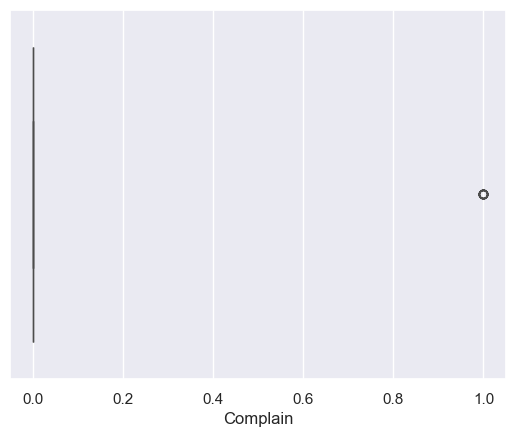

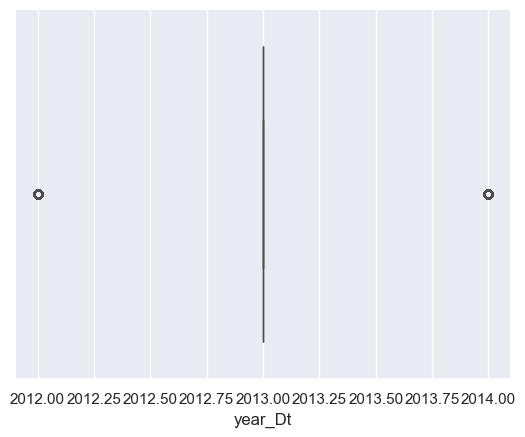

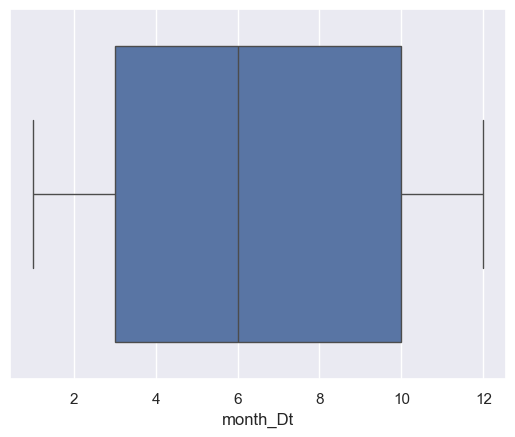

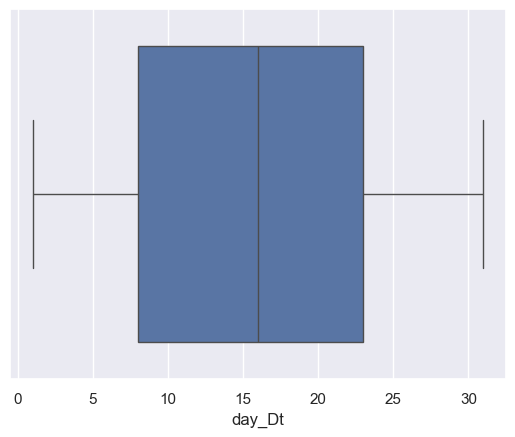

In [13]:
for i in data.columns:
    sns.boxplot(x=i, data=data)
    plt.show()

In [14]:
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

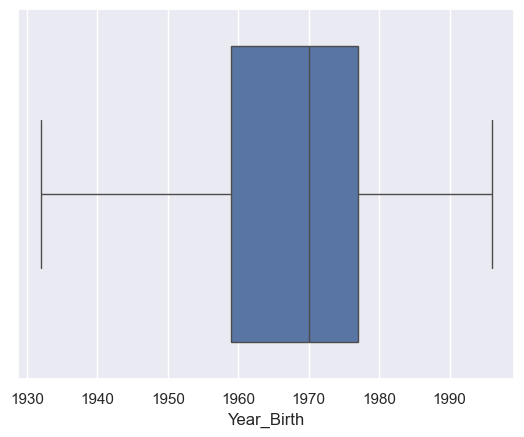

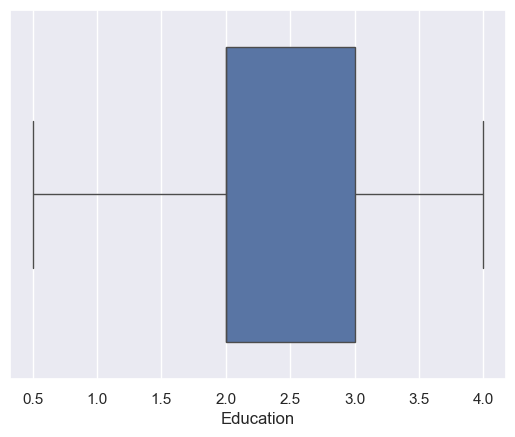

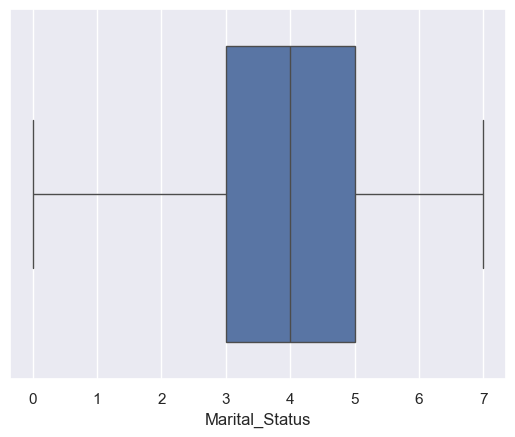

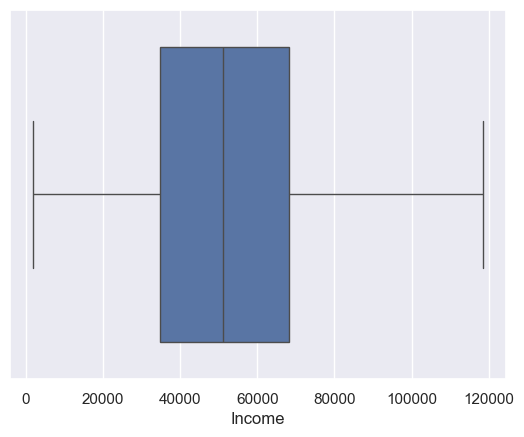

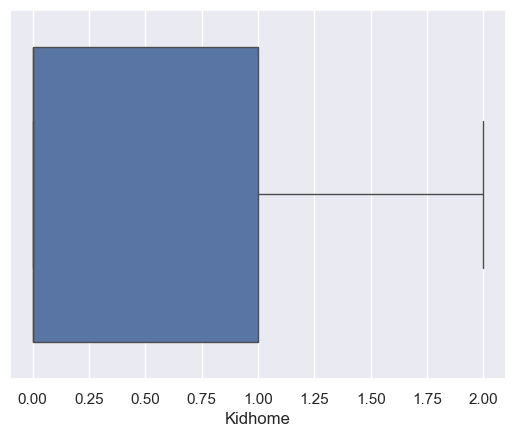

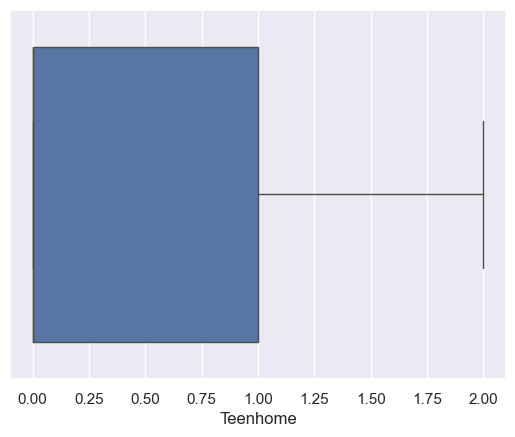

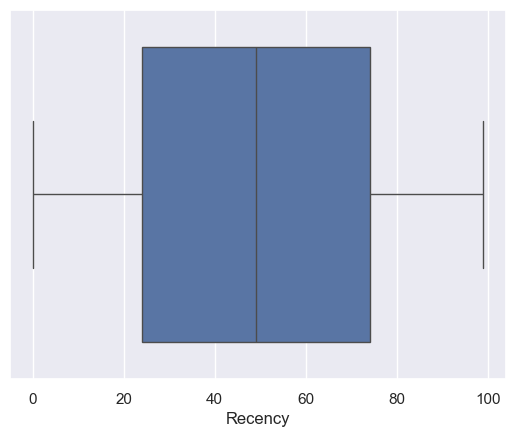

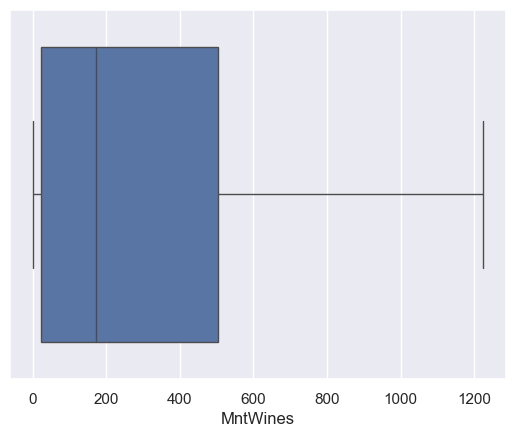

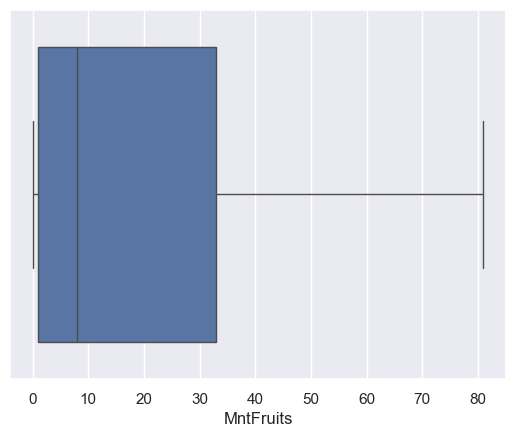

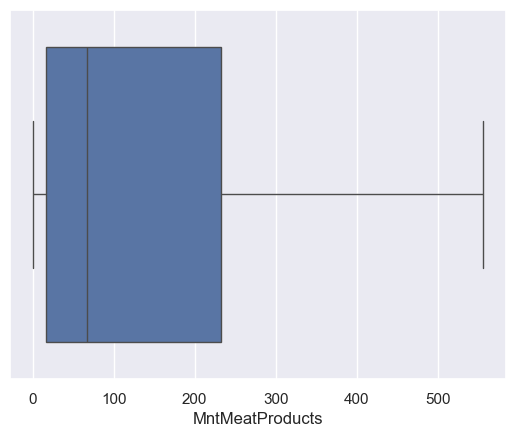

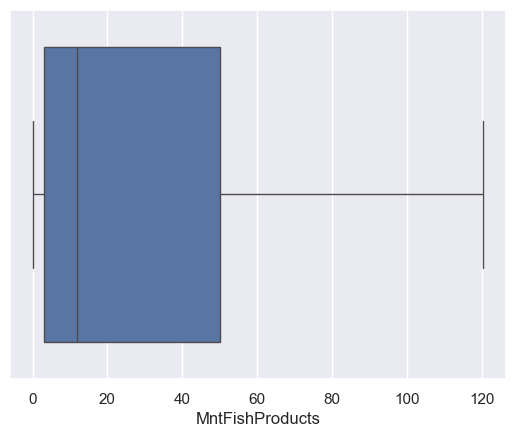

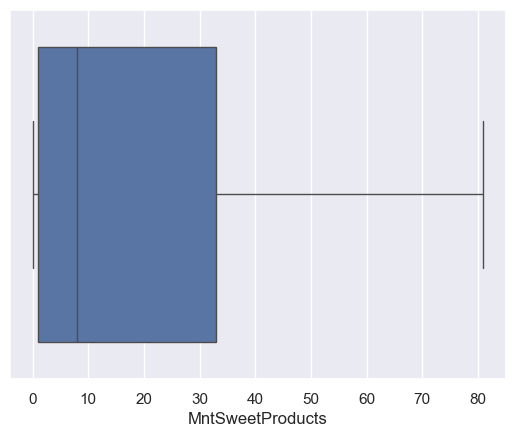

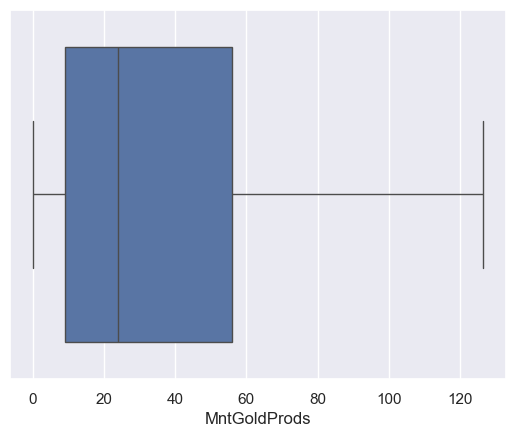

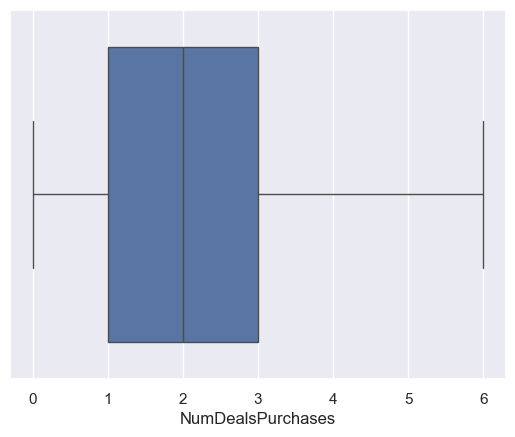

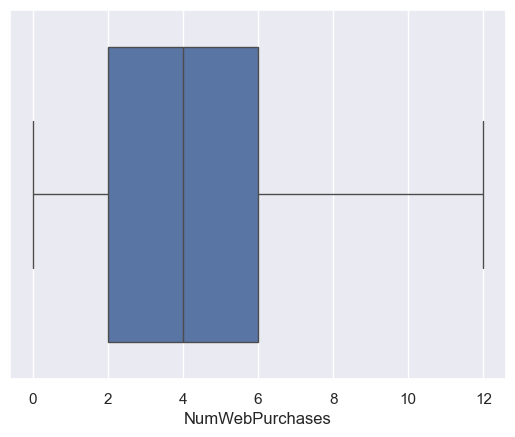

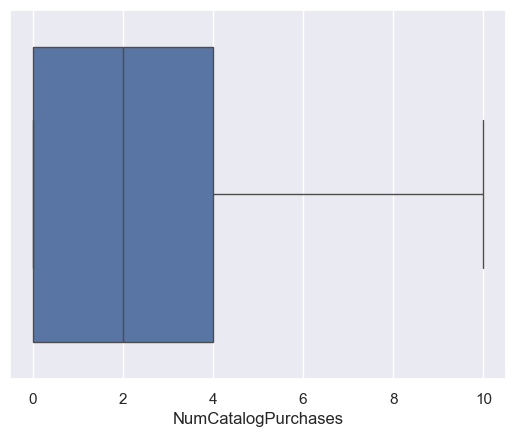

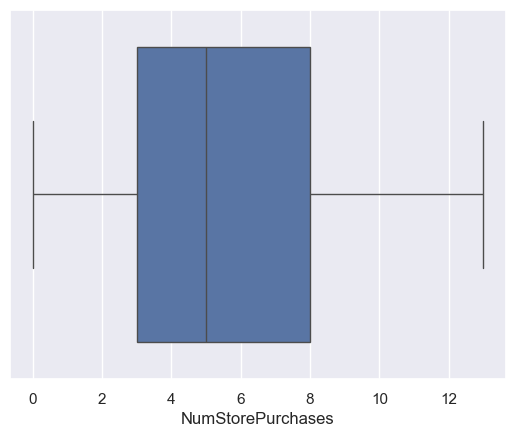

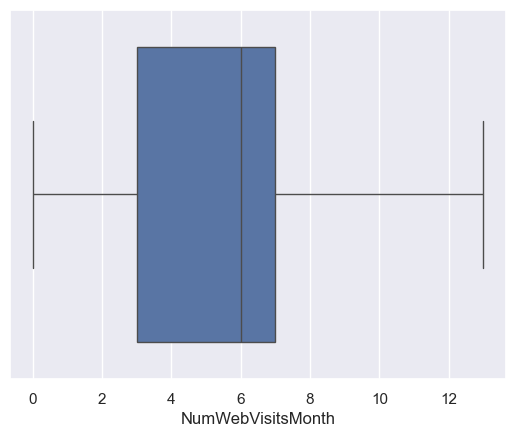

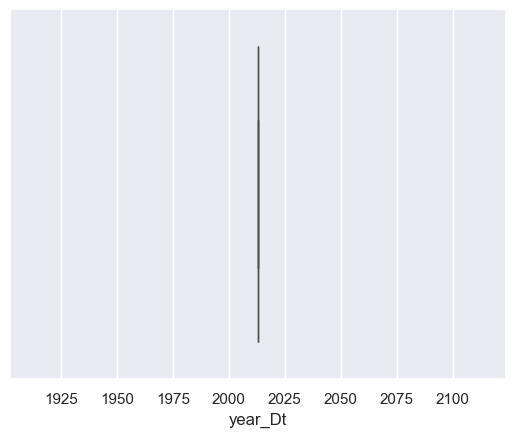

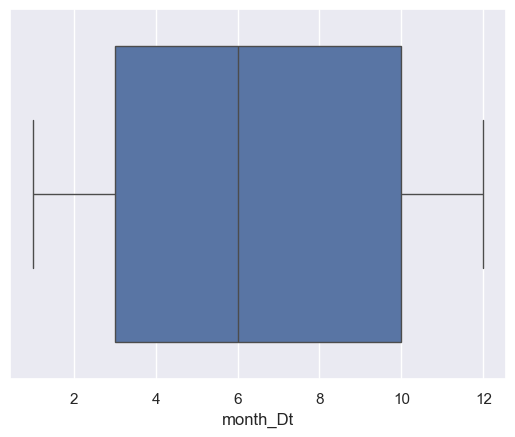

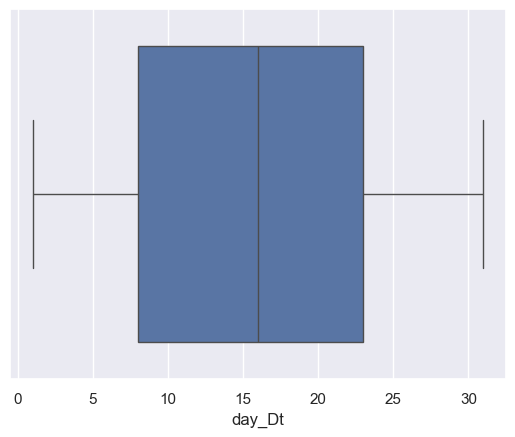

In [15]:
for i in data.columns:
    if data[i].nunique() > 2:
        data[i]=np.where(data[i]>Upper[i],Upper[i],data[i])
        data[i]=np.where(data[i]<Lower[i],Lower[i],data[i])
        sns.boxplot(x=i, data=data)
        plt.show()

In [16]:
sc = MinMaxScaler(feature_range = (0, 1))
inputs_scaled = sc.fit_transform(data)
data_scaled = pd.DataFrame(inputs_scaled, columns=data.columns)

K Means

In [17]:
wcss = []
silhouette_scores = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)  
    kmeans.fit(data_scaled)
    
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)
    
    print(f"Cluster {i}: WCSS = {wcss_iter:.4f}")  # Print WCSS first
    
    if i > 1:  # Calculate silhouette score only if k >= 2
        y = kmeans.predict(data_scaled)
        silhouette_avg = silhouette_score(data_scaled, y)
        silhouette_scores.append(silhouette_avg)
        print(f"Silhouette Score = {silhouette_avg:.4f}")  
    else:
        print(" (Silhouette Score not applicable for k=1)")  


C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Cluster 1: WCSS = 3996.8730
 (Silhouette Score not applicable for k=1)
Cluster 2: WCSS = 2959.4278
Silhouette Score = 0.2715
Cluster 3: WCSS = 2707.2151
Silhouette Score = 0.1689
Cluster 4: WCSS = 2590.4029
Silhouette Score = 0.1621
Cluster 5: WCSS = 2504.3779
Silhouette Score = 0.0882
Cluster 6: WCSS = 2370.4817


C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette Score = 0.0969
Cluster 7: WCSS = 2323.8940
Silhouette Score = 0.0990
Cluster 8: WCSS = 2316.8544
Silhouette Score = 0.0711
Cluster 9: WCSS = 2211.8421


C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette Score = 0.0773


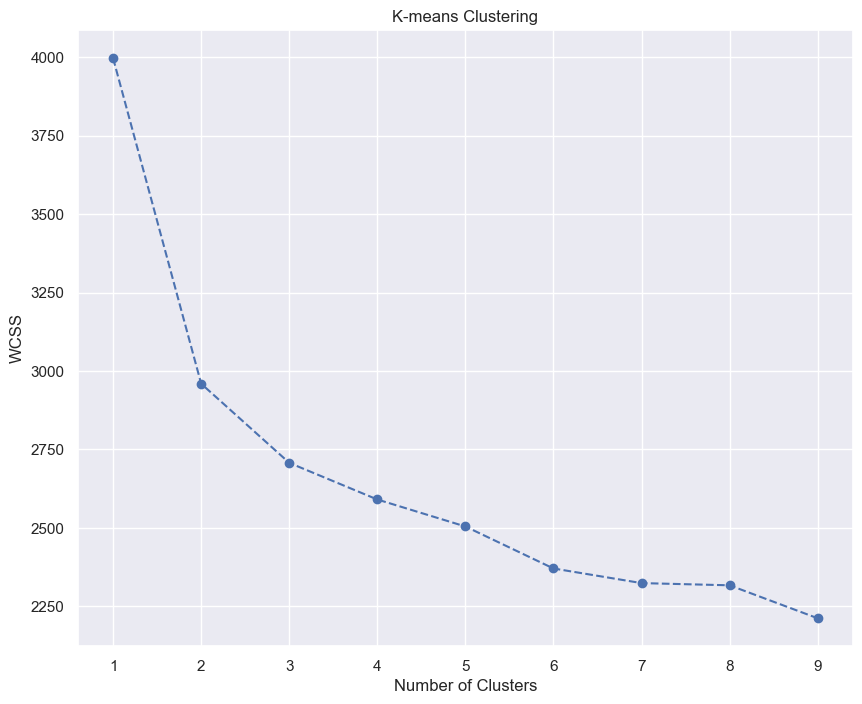

In [18]:
plt.figure(figsize = (10,8))
plt.plot(range(1, 10), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')
plt.show()

The optimal number of clusters (elbow point) is: 3


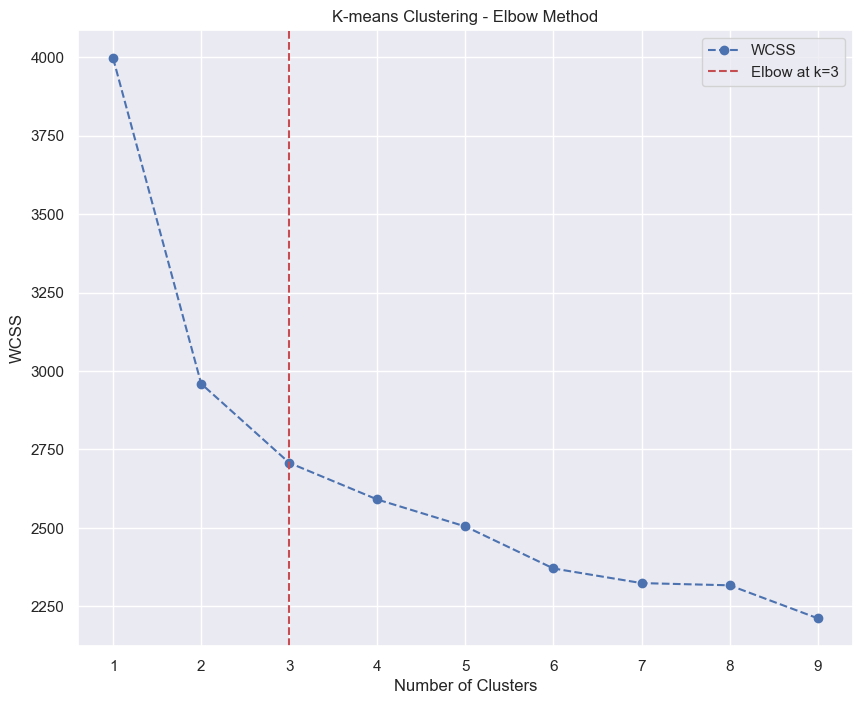

In [19]:
# Automatically find the "elbow"
knee_locator = KneeLocator(range(1, 10), wcss, curve="convex", direction="decreasing")

#Convex Curve: The plot is shaped like a gradually flattening downward curve.
#WCSS is always decreasing as we increase the number of clusters.

# Get the elbow point
optimal_k = knee_locator.elbow
print(f"The optimal number of clusters (elbow point) is: {optimal_k}")

# Plot with the elbow point marked
plt.figure(figsize=(10, 8))
plt.plot(range(1, 10), wcss, marker="o", linestyle="--", label="WCSS")
plt.axvline(optimal_k, linestyle="--", color="r", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("K-means Clustering - Elbow Method")
plt.legend()
plt.show()


In [20]:
kmeans = KMeans(3)
kmeans.fit(data_scaled)

C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


KMeans(n_clusters=3)

In [21]:
data['Segments'] = kmeans.predict(data_scaled)
data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0
2236,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2
2237,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2
2238,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2


In [22]:
df_segm_analysis = data.groupby(['Segments'], as_index=False).mean()
df_segm_analysis['data count'] = data[['Segments','Income']].groupby(['Segments']).count()
df_segm_analysis['data proportion'] = df_segm_analysis['data count'] / df_segm_analysis['data count'].sum()

df_segm_analysis

,Segments,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,data count,data proportion
0,0,1968.324493,2.342434,3.764431,73713.603744,0.060842,0.248050,50.218409,581.819033,53.525741,378.193448,81.478939,54.909516,68.433697,1.469579,5.443058,5.625585,8.527301,3.170047,0.078003,0.106084,0.230889,0.191888,0.023401,0.007800,2013.0,6.441498,15.266771,641,0.286161
1,1,1971.446583,2.318094,3.712223,34482.737488,0.793070,0.451396,49.106833,41.893167,4.684312,24.068335,6.698749,4.855630,14.322425,2.011550,2.110683,0.546679,3.191530,6.405197,0.071222,0.008662,0.000000,0.000000,0.001925,0.012512,2013.0,6.261790,15.795958,1039,0.463839
2,2,1964.642857,2.774107,3.723214,57246.820982,0.235714,0.903571,47.844643,464.750000,16.757143,125.941071,22.770536,15.891071,53.045536,3.448214,6.096429,3.042857,7.478571,5.683929,0.069643,0.160714,0.026786,0.037500,0.023214,0.005357,2013.0,6.878571,15.771429,560,0.250000


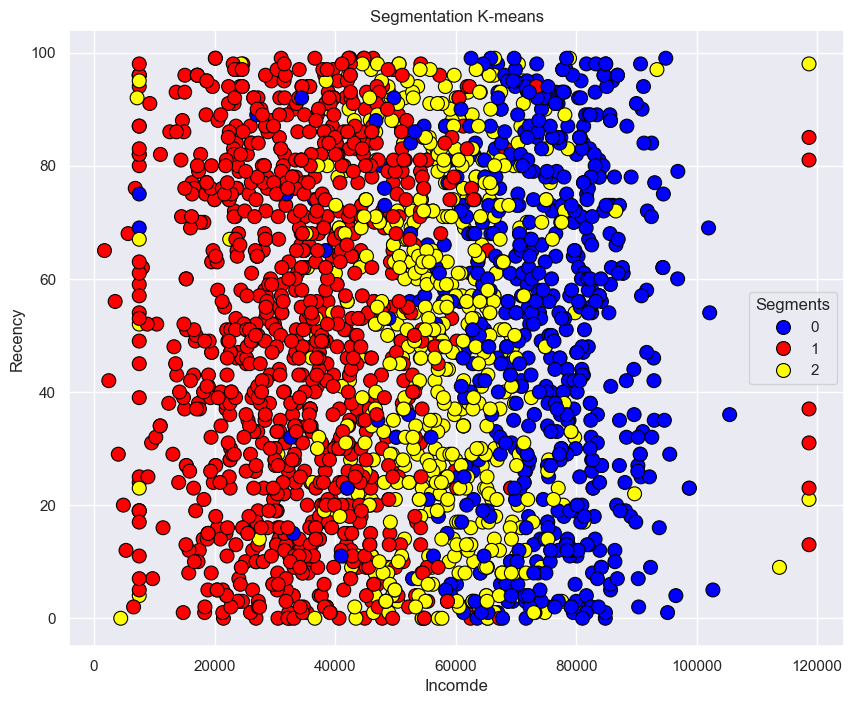

In [23]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Income'], y=data['Recency'], hue=data['Segments'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Incomde")
plt.ylabel("Recency")
plt.legend(title="Segments")
plt.show()

In [24]:

pca = PCA()

pca.fit(data_scaled)

pca.explained_variance_ratio_

array([3.21339311e-01, 8.01124572e-02, 6.75290714e-02, 5.63521149e-02,
       4.96906610e-02, 4.88020421e-02, 4.77956508e-02, 4.27005359e-02,
       3.44154945e-02, 2.96060845e-02, 2.53992163e-02, 2.28070647e-02,
       2.24425100e-02, 2.07326356e-02, 1.95282720e-02, 1.69762463e-02,
       1.48238876e-02, 1.33748463e-02, 1.28039080e-02, 1.21772418e-02,
       1.07088195e-02, 8.65480015e-03, 6.57683889e-03, 6.13172274e-03,
       5.13078722e-03, 3.38778001e-03, 5.64128376e-20])

Text(0, 0.5, 'Cumulative Explained Variance')

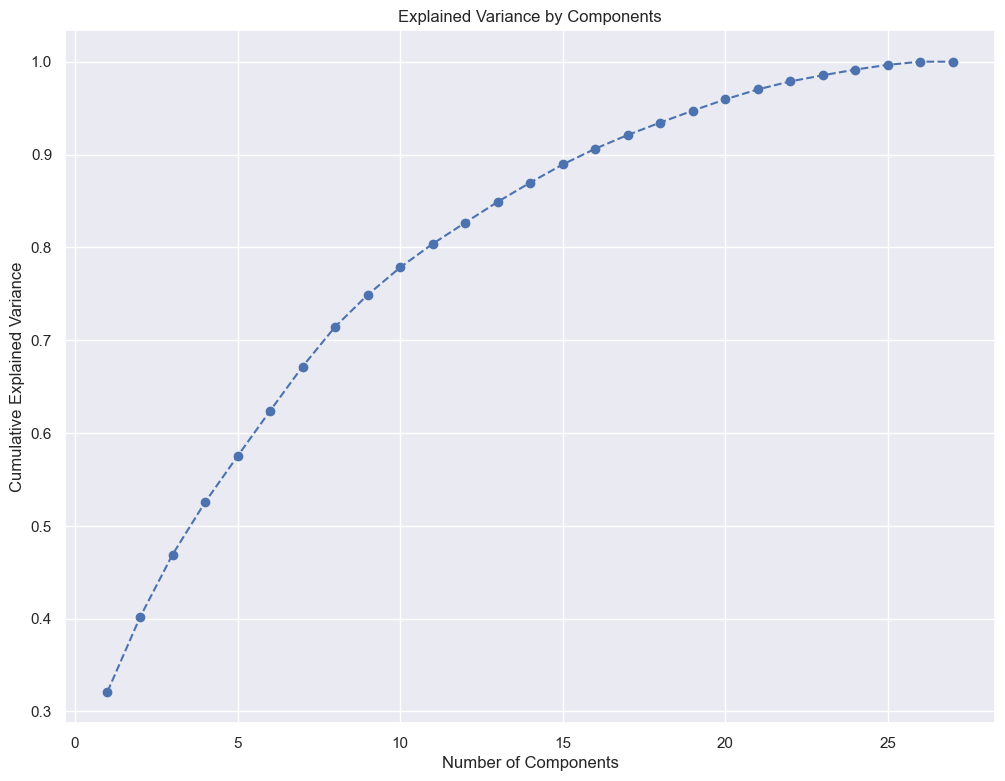

In [25]:
plt.figure(figsize = (12,9))
plt.plot(range(1,28), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [26]:
pca = PCA(n_components = 12)

pca.fit(data_scaled)

pca.components_

array([[-2.75618730e-02, -9.35741625e-04,  4.63651054e-03,
         1.94502953e-01, -2.24168328e-01, -6.27271006e-02,
         7.19108541e-03,  2.67615004e-01,  3.54735941e-01,
         3.69381874e-01,  3.61522618e-01,  3.63432661e-01,
         2.65399749e-01, -5.60393267e-02,  1.59729272e-01,
         3.02730543e-01,  2.39313331e-01, -1.45773251e-01,
         1.36390497e-02,  6.12650256e-02,  1.47791427e-01,
         1.22623598e-01,  1.48042330e-02, -3.75504650e-03,
        -3.57985885e-36,  1.03532068e-02, -7.23751159e-03],
       [-1.93948119e-01,  3.85052188e-01, -8.03857366e-04,
         1.00701957e-01, -1.19962473e-01,  4.92900006e-01,
         1.20859759e-02,  2.97926204e-01, -1.75703802e-01,
        -7.01248532e-02, -2.06952764e-01, -1.76646957e-01,
         9.41940759e-02,  3.76713484e-01,  2.71921449e-01,
         8.04367393e-02,  1.94308617e-01,  8.06686756e-02,
        -1.20670338e-02,  2.60747496e-01,  1.72157193e-02,
         1.07663240e-02,  4.05527450e-02, -8.15502502e-

In [27]:
df_pca_comp = pd.DataFrame(data = pca.components_,
                           columns = data.columns[:-1].values,
                           index = ['Component 1', 'Component 2', 'Component 3',
                                    'Component 4', 'Component 5', 'Component 6',
                                   'Component 7','Component 8', 'Component 9', 'Component 10',
                                    'Component 11', 'Component 12'])
df_pca_comp

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt
Component 1,-0.027562,-0.000936,0.004637,0.194503,-0.224168,-0.062727,0.007191,0.267615,0.354736,0.369382,0.361523,0.363433,0.265400,-0.056039,0.159729,0.302731,0.239313,-0.145773,0.013639,0.061265,0.147791,0.122624,0.014804,-0.003755,-3.579859e-36,0.010353,-0.007238
Component 2,-0.193948,0.385052,-0.000804,0.100702,-0.119962,0.492900,0.012086,0.297926,-0.175704,-0.070125,-0.206953,-0.176647,0.094194,0.376713,0.271921,0.080437,0.194309,0.080669,-0.012067,0.260747,0.017216,0.010766,0.040553,-0.008155,2.432132e-27,0.036729,0.028975
Component 3,0.025413,0.297524,0.002313,0.074120,-0.041038,-0.266932,-0.049084,0.179441,-0.193703,0.106046,-0.144105,-0.150589,-0.306649,-0.365860,-0.141753,0.055714,-0.077014,-0.093230,0.039145,0.346698,0.423313,0.304425,0.083145,-0.007276,6.192243e-25,-0.198034,0.009341
Component 4,0.060372,0.012943,0.010145,-0.020660,0.006084,-0.136299,0.062617,0.070779,-0.063733,0.037888,-0.054558,-0.029197,-0.028994,-0.057247,-0.021391,0.020884,-0.030949,0.047886,0.010814,0.084796,0.068716,0.067922,0.016586,-0.002987,-5.816114e-24,0.966130,0.013819
Component 5,-0.133209,0.583235,0.018077,0.063280,-0.144074,0.037874,0.116967,-0.074799,0.108545,0.105875,0.061952,0.068354,-0.331591,-0.213066,-0.111867,0.008703,0.054606,-0.170394,-0.302430,-0.291908,-0.267926,-0.281091,-0.079139,-0.005246,-1.323489e-23,0.066179,0.163385
Component 6,0.009998,-0.192749,0.000301,-0.015558,0.023197,0.003276,0.748626,0.011554,-0.022721,-0.016507,-0.038151,0.038415,0.030036,0.009809,-0.003075,-0.017346,-0.008369,0.014465,-0.099523,0.146621,0.053485,0.046105,0.026191,0.002764,0.000000e+00,-0.076211,0.594292
Component 7,0.026532,0.014565,-0.019835,-0.008988,-0.010853,-0.038642,-0.587483,0.000918,0.001723,-0.010051,-0.015736,0.004980,0.069491,-0.001521,0.037487,-0.008099,-0.003912,0.038048,0.152643,-0.067686,-0.023774,0.032332,0.007898,-0.006768,-1.058791e-22,0.023837,0.783296
Component 8,0.052601,0.372592,-0.016033,-0.025736,0.134038,-0.126512,0.259534,0.019047,-0.017392,0.058455,-0.053236,-0.076573,0.227232,0.016399,0.020347,0.128509,-0.123841,0.042498,0.720007,-0.370950,0.005594,0.004037,-0.015416,-0.001849,-5.293956e-23,-0.030681,-0.012700
Component 9,0.223211,0.255443,-0.022817,-0.038137,0.621664,-0.240568,-0.018502,0.060002,0.155626,0.102133,0.101881,0.194831,-0.224006,0.442128,0.123640,-0.058192,0.046361,0.182260,-0.190890,0.051524,0.063295,0.082594,-0.017110,0.001126,-0.000000e+00,-0.037831,0.018337
Component 10,0.150045,0.186616,0.012158,-0.059124,-0.035531,-0.448559,-0.011226,0.044611,-0.076031,0.027604,-0.080474,-0.326927,0.622577,-0.050998,0.050246,-0.025099,0.043161,0.045536,-0.373920,0.073984,-0.050514,-0.254756,0.004593,-0.018168,0.000000e+00,-0.063757,-0.009045


In [28]:
scores_pca = pca.transform(data_scaled)

pca_df = pd.DataFrame(scores_pca, columns=[f'Variable_{i+1}' for i in range(scores_pca.shape[1])])

pca_df

,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10,Variable_11,Variable_12
0,1.507096,-0.287798,-0.500426,0.164060,0.037617,-0.199491,-0.328674,0.092125,0.235906,0.005709,-0.068639,-0.125493
1,-0.765365,-0.050306,0.061948,-0.347585,-0.028238,-0.188056,-0.190111,-0.127731,-0.112830,-0.189413,0.180893,0.070110
2,0.581565,-0.225889,-0.185450,0.068498,0.163341,-0.111797,0.277786,-0.232234,-0.065104,0.093920,-0.178300,-0.170648
3,-0.719367,-0.384027,0.167975,-0.351174,-0.126788,-0.228313,-0.033812,-0.100621,0.181111,0.119835,-0.058102,-0.083044
4,-0.006727,0.026113,-0.025794,-0.473815,0.311238,0.342771,-0.190100,0.298018,0.707996,0.080467,-0.127899,-0.023161
...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.756375,0.129311,-0.508190,-0.141724,-0.168105,-0.024229,-0.001133,-0.010854,-0.150674,0.103060,0.097233,0.332267
2236,-0.507752,0.751375,0.173005,-0.024926,-0.217129,-0.081872,-0.184353,0.209368,0.791170,-0.359787,0.711101,-0.283519
2237,0.435536,0.141818,0.541710,-0.314314,-0.092539,0.677122,-0.086106,-0.382824,0.023898,0.252390,-0.852947,-0.125503
2238,0.569586,0.247018,-0.079964,-0.604802,0.251014,-0.177317,0.430259,-0.137644,-0.150778,0.016974,0.089385,-0.118555


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss_pca = []
silhouette_scores_pca = []

for i in range(1, 8):
    kmeans_pca = KMeans(n_clusters=i, random_state=42)  
    kmeans_pca.fit(pca_df)
    
    wcss_iter = kmeans_pca.inertia_
    wcss_pca.append(wcss_iter)
    
    print(f"Cluster {i}: WCSS = {wcss_iter:.4f}")  
    
    if i > 1: 
        y = kmeans_pca.predict(pca_df)
        silhouette_avg = silhouette_score(pca_df, y)
        silhouette_scores_pca.append(silhouette_avg)
        print(f"Silhouette Score = {silhouette_avg:.4f}")  
    else:
        print(" (Silhouette Score not applicable for k=1)") 

C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when the

Cluster 1: WCSS = 3303.6142
 (Silhouette Score not applicable for k=1)
Cluster 2: WCSS = 2266.6827
Silhouette Score = 0.3064
Cluster 3: WCSS = 2016.3153
Silhouette Score = 0.2054
Cluster 4: WCSS = 1857.4471
Silhouette Score = 0.2005
Cluster 5: WCSS = 1772.6517
Silhouette Score = 0.1287
Cluster 6: WCSS = 1721.6671
Silhouette Score = 0.1064
Cluster 7: WCSS = 1657.0242


C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette Score = 0.0998


The optimal number of clusters (elbow point) is: 2


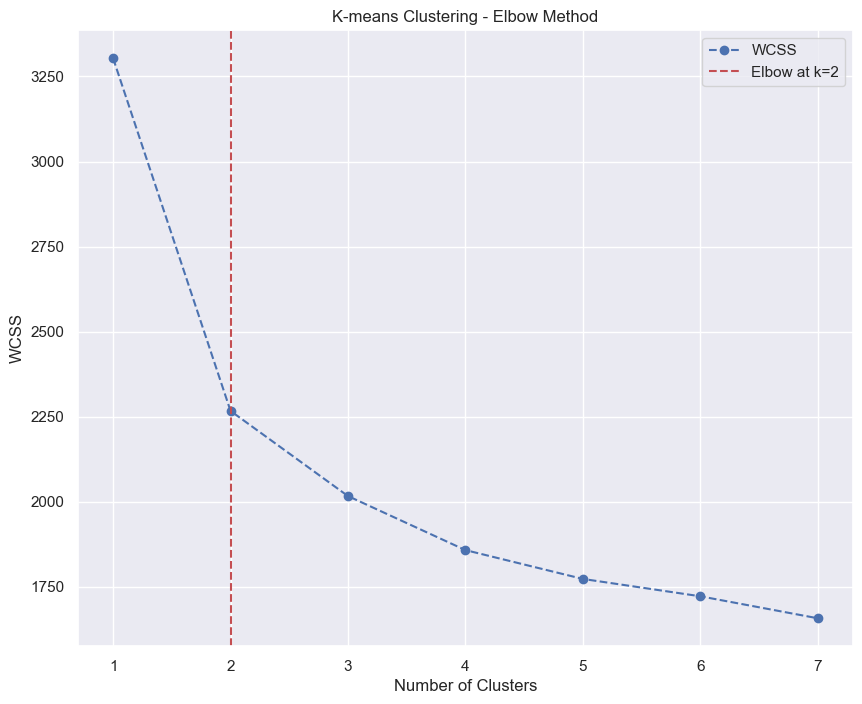

In [30]:
from kneed import KneeLocator

knee_locator = KneeLocator(range(1, 8), wcss_pca, curve="convex", direction="decreasing")

optimal_k = knee_locator.elbow
print(f"The optimal number of clusters (elbow point) is: {optimal_k}")

plt.figure(figsize=(10, 8))
plt.plot(range(1, 8), wcss_pca, marker="o", linestyle="--", label="WCSS")
plt.axvline(optimal_k, linestyle="--", color="r", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("K-means Clustering - Elbow Method")
plt.legend()
plt.show()


In [31]:
kmeans_pca = KMeans(2)
kmeans_pca.fit(pca_df)

C:\Users\user\aysel\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


KMeans(n_clusters=2)

In [32]:
data['Segments_pca'] = kmeans_pca.predict(pca_df)
data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments,Segments_pca
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0,1
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1,0
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0,1
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1,0
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0,1
2236,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2,0
2237,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2,1
2238,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2,1


In [33]:
data = pd.concat([data,pca_df], axis=1)

data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments,Segments_pca,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10,Variable_11,Variable_12
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0,1,1.507096,-0.287798,-0.500426,0.164060,0.037617,-0.199491,-0.328674,0.092125,0.235906,0.005709,-0.068639,-0.125493
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1,0,-0.765365,-0.050306,0.061948,-0.347585,-0.028238,-0.188056,-0.190111,-0.127731,-0.112830,-0.189413,0.180893,0.070110
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0,1,0.581565,-0.225889,-0.185450,0.068498,0.163341,-0.111797,0.277786,-0.232234,-0.065104,0.093920,-0.178300,-0.170648
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1,0,-0.719367,-0.384027,0.167975,-0.351174,-0.126788,-0.228313,-0.033812,-0.100621,0.181111,0.119835,-0.058102,-0.083044
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2,0,-0.006727,0.026113,-0.025794,-0.473815,0.311238,0.342771,-0.190100,0.298018,0.707996,0.080467,-0.127899,-0.023161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0,1,0.756375,0.129311,-0.508190,-0.141724,-0.168105,-0.024229,-0.001133,-0.010854,-0.150674,0.103060,0.097233,0.332267
2236,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2,0,-0.507752,0.751375,0.173005,-0.024926,-0.217129,-0.081872,-0.184353,0.209368,0.791170,-0.359787,0.711101,-0.283519
2237,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2,1,0.435536,0.141818,0.541710,-0.314314,-0.092539,0.677122,-0.086106,-0.382824,0.023898,0.252390,-0.852947,-0.125503
2238,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2,1,0.569586,0.247018,-0.079964,-0.604802,0.251014,-0.177317,0.430259,-0.137644,-0.150778,0.016974,0.089385,-0.118555


C:\Users\user\AppData\Local\Temp\ipykernel_11272\3716005506.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(x=data['Variable_2'], y=data['Variable_1'], hue=data['Segments_pca'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")


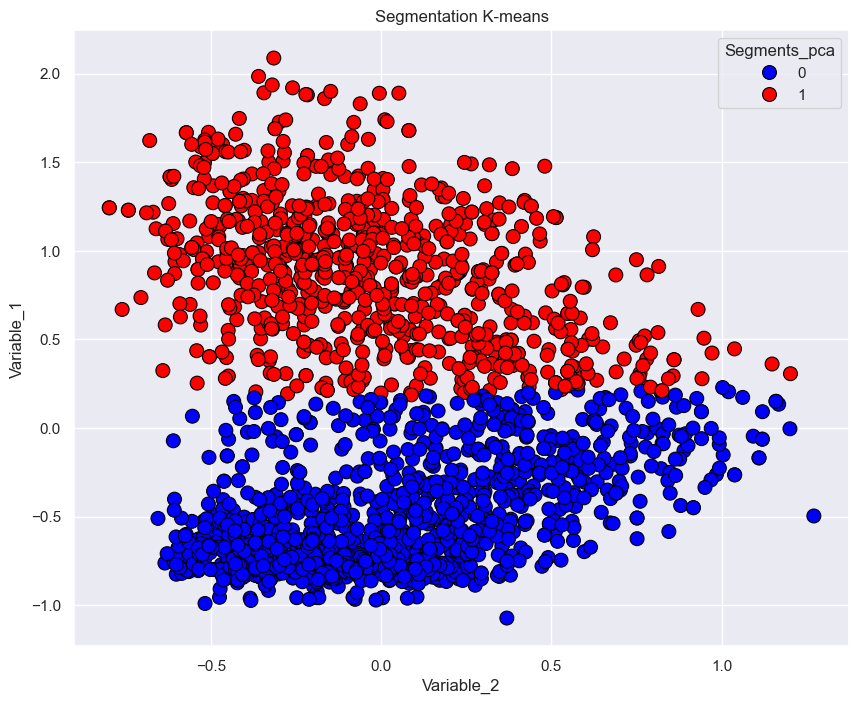

In [34]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Variable_2'], y=data['Variable_1'], hue=data['Segments_pca'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Variable_2")
plt.ylabel("Variable_1")
plt.legend(title="Segments_pca")
plt.show()

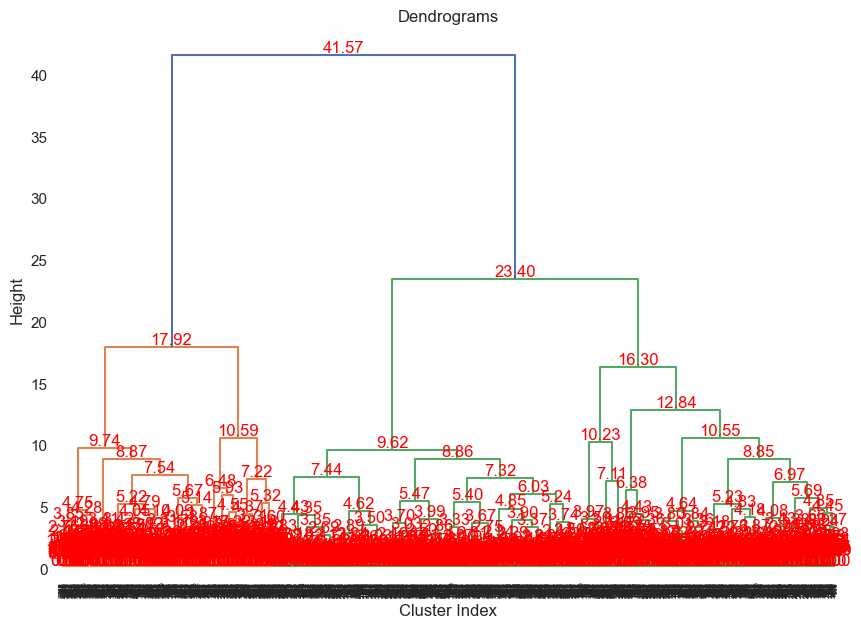

In [35]:
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

# Label heights
for x, y in zip(dend['icoord'], dend['dcoord']):
    plt.text((x[1] + x[2]) / 2, y[1], f"{y[1]:.2f}", ha='center', va='bottom', color='red')

plt.xlabel("Cluster Index")
plt.ylabel("Height")
plt.show()


In [36]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2,linkage='ward')  
y = cluster.fit_predict(data)

y

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [37]:
data['segment_HC'] = y

data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments,Segments_pca,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10,Variable_11,Variable_12,segment_HC
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0,1,1.507096,-0.287798,-0.500426,0.164060,0.037617,-0.199491,-0.328674,0.092125,0.235906,0.005709,-0.068639,-0.125493,0
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1,0,-0.765365,-0.050306,0.061948,-0.347585,-0.028238,-0.188056,-0.190111,-0.127731,-0.112830,-0.189413,0.180893,0.070110,0
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0,1,0.581565,-0.225889,-0.185450,0.068498,0.163341,-0.111797,0.277786,-0.232234,-0.065104,0.093920,-0.178300,-0.170648,0
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1,0,-0.719367,-0.384027,0.167975,-0.351174,-0.126788,-0.228313,-0.033812,-0.100621,0.181111,0.119835,-0.058102,-0.083044,1
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2,0,-0.006727,0.026113,-0.025794,-0.473815,0.311238,0.342771,-0.190100,0.298018,0.707996,0.080467,-0.127899,-0.023161,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0,1,0.756375,0.129311,-0.508190,-0.141724,-0.168105,-0.024229,-0.001133,-0.010854,-0.150674,0.103060,0.097233,0.332267,0
2236,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2,0,-0.507752,0.751375,0.173005,-0.024926,-0.217129,-0.081872,-0.184353,0.209368,0.791170,-0.359787,0.711101,-0.283519,0
2237,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2,1,0.435536,0.141818,0.541710,-0.314314,-0.092539,0.677122,-0.086106,-0.382824,0.023898,0.252390,-0.852947,-0.125503,0
2238,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2,1,0.569586,0.247018,-0.079964,-0.604802,0.251014,-0.177317,0.430259,-0.137644,-0.150778,0.016974,0.089385,-0.118555,0


In [38]:
silhouette_avg = silhouette_score(data, y)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.528658959286881


C:\Users\user\AppData\Local\Temp\ipykernel_11272\1273130469.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(x=data['Income'], y=data['Recency'], hue=data['segment_HC'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")


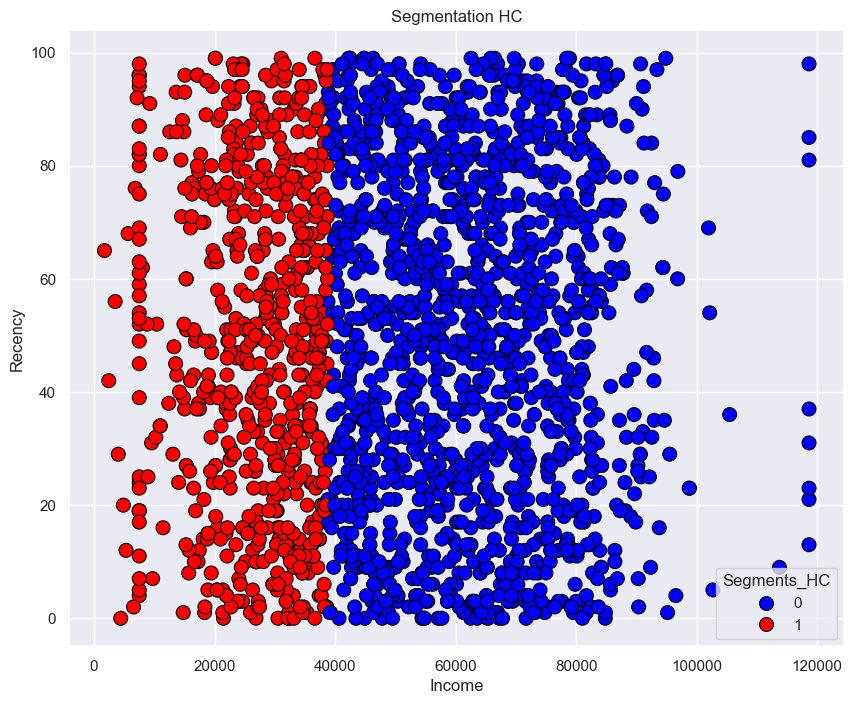

In [39]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Income'], y=data['Recency'], hue=data['segment_HC'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation HC')
plt.xlabel("Income")
plt.ylabel("Recency")
plt.legend(title="Segments_HC")
plt.show()

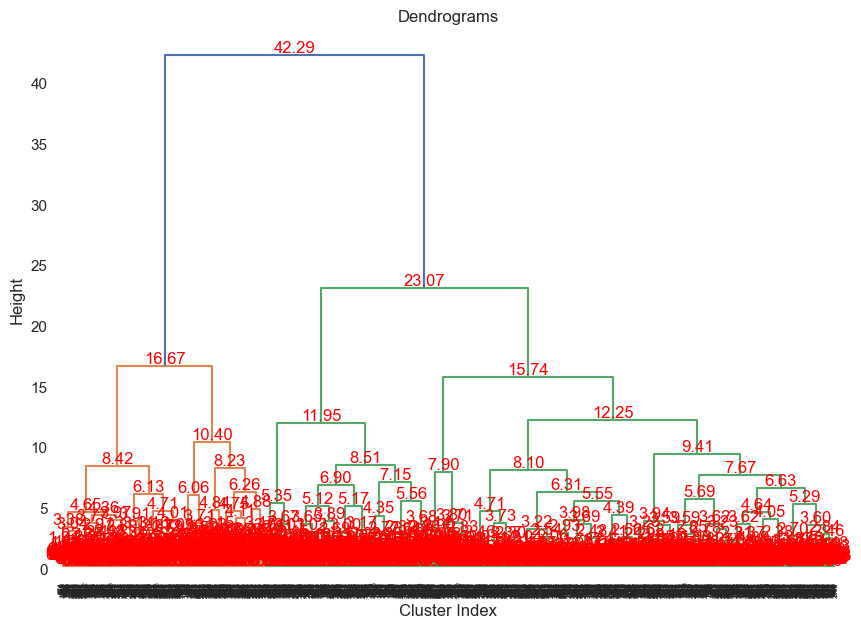

In [40]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

dend = shc.dendrogram(shc.linkage(pca_df, method='ward'))

# Label heights
for x, y in zip(dend['icoord'], dend['dcoord']):
    plt.text((x[1] + x[2]) / 2, y[1], f"{y[1]:.2f}", ha='center', va='bottom', color='red')

plt.xlabel("Cluster Index")
plt.ylabel("Height")
plt.show()


In [41]:
cluster = AgglomerativeClustering(n_clusters=2, linkage='ward')  
y_pca = cluster.fit_predict(pca_df)

In [42]:
data['segment_HC_pca'] = y_pca

data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments,Segments_pca,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10,Variable_11,Variable_12,segment_HC,segment_HC_pca
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0,1,1.507096,-0.287798,-0.500426,0.164060,0.037617,-0.199491,-0.328674,0.092125,0.235906,0.005709,-0.068639,-0.125493,0,1
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1,0,-0.765365,-0.050306,0.061948,-0.347585,-0.028238,-0.188056,-0.190111,-0.127731,-0.112830,-0.189413,0.180893,0.070110,0,0
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0,1,0.581565,-0.225889,-0.185450,0.068498,0.163341,-0.111797,0.277786,-0.232234,-0.065104,0.093920,-0.178300,-0.170648,0,1
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1,0,-0.719367,-0.384027,0.167975,-0.351174,-0.126788,-0.228313,-0.033812,-0.100621,0.181111,0.119835,-0.058102,-0.083044,1,0
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2,0,-0.006727,0.026113,-0.025794,-0.473815,0.311238,0.342771,-0.190100,0.298018,0.707996,0.080467,-0.127899,-0.023161,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0,1,0.756375,0.129311,-0.508190,-0.141724,-0.168105,-0.024229,-0.001133,-0.010854,-0.150674,0.103060,0.097233,0.332267,0,1
2236,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2,0,-0.507752,0.751375,0.173005,-0.024926,-0.217129,-0.081872,-0.184353,0.209368,0.791170,-0.359787,0.711101,-0.283519,0,0
2237,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2,1,0.435536,0.141818,0.541710,-0.314314,-0.092539,0.677122,-0.086106,-0.382824,0.023898,0.252390,-0.852947,-0.125503,0,1
2238,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2,1,0.569586,0.247018,-0.079964,-0.604802,0.251014,-0.177317,0.430259,-0.137644,-0.150778,0.016974,0.089385,-0.118555,0,0


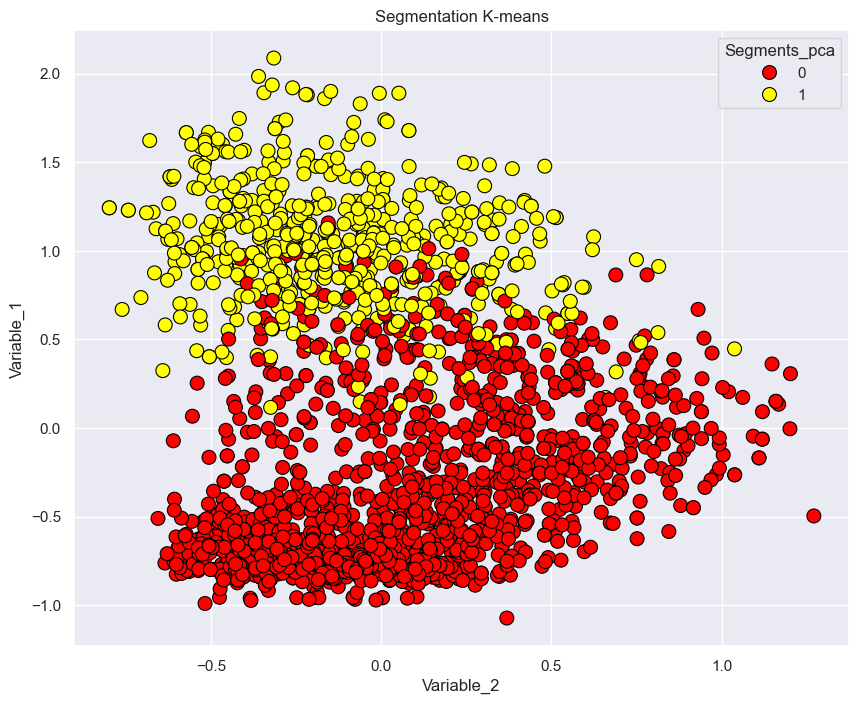

In [43]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Variable_2'], y=data['Variable_1'], hue=data['segment_HC_pca'], palette=['red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Variable_2")
plt.ylabel("Variable_1")
plt.legend(title="Segments_pca")
plt.show()

In [44]:
import optuna
from sklearn.metrics import silhouette_score

def objective(trial):

    x = trial.suggest_int("x", 10, 20)  # Grid size x
    y = trial.suggest_int("y", 10, 20)  # Grid size y
    sigma = trial.suggest_float("sigma", 0.1, 2.0, log=True)  # Spread of the neighborhood
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)  # Learning rate
    num_iteration = trial.suggest_int("num_iteration", 50, 500)  # Training iterations

    # Initialize SOM
    som = MiniSom(x=x, y=y, input_len=inputs_scaled.shape[1], sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(inputs_scaled)
    som.train_random(data=inputs_scaled, num_iteration=num_iteration)
    
    # Assign each input to the closest SOM neuron
    labels = np.array([som.winner(x) for x in inputs_scaled])
    print(labels)
    # Flatten the neuron indices for silhouette_score
    flattened_labels = [i[0] * y + i[1] for i in labels]
    
    # Evaluate clustering using silhouette score (higher is better)
    try:
        score = silhouette_score(inputs_scaled, flattened_labels)
    except ValueError:
        score = -1  # Assign a negative score if clustering fails
    
    return score

# Run the optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1)

# Display the best parameters
print("Best parameters:", study.best_params)
print("Best silhouette score:", study.best_value)


[I 2025-09-27 21:39:08,579] A new study created in memory with name: no-name-6e4bd777-4f99-4eef-bf27-6259ace54ca8
[I 2025-09-27 21:39:08,695] Trial 0 finished with value: 0.045681766795395276 and parameters: {'x': 14, 'y': 15, 'sigma': 0.10702373657445512, 'learning_rate': 0.5288067725714035, 'num_iteration': 153}. Best is trial 0 with value: 0.045681766795395276.


[[ 1 13]
 [ 6  0]
 [ 1  2]
 ...
 [11 11]
 [ 8  6]
 [ 7  1]]
Best parameters: {'x': 14, 'y': 15, 'sigma': 0.10702373657445512, 'learning_rate': 0.5288067725714035, 'num_iteration': 153}
Best silhouette score: 0.045681766795395276


In [45]:
best_params = study.best_params
best_params

{'x': 14,
 'y': 15,
 'sigma': 0.10702373657445512,
 'learning_rate': 0.5288067725714035,
 'num_iteration': 153}

In [46]:
# Initialize SOM with the best parameters
som_opt = MiniSom(x=best_params['x'], y=best_params['y'], input_len=27,
              sigma=best_params['sigma'], learning_rate=best_params['learning_rate'])

som_opt.random_weights_init(inputs_scaled)

som_opt.train_random(data=inputs_scaled, num_iteration=best_params['num_iteration'])


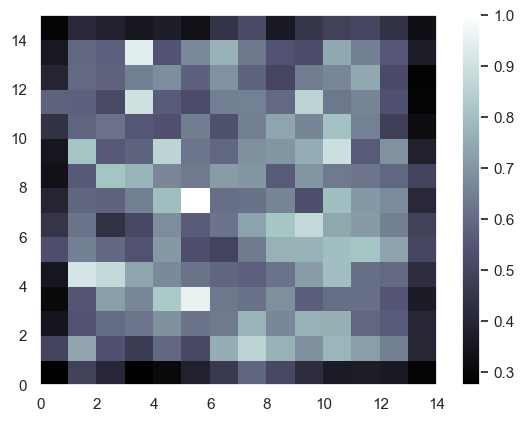

In [47]:
# Original Plot Code
bone()
pcolor(som_opt.distance_map().T)  # Display the distance map
colorbar()


In [48]:
distance_map = som_opt.distance_map()

threshold = 0.9

white_nodes = [(i, j) for i in range(distance_map.shape[0]) for j in range(distance_map.shape[1]) if distance_map[i, j] >= threshold]

print("Positions of Nodes (Distance >= 0.9):")
for node in white_nodes:
    print(f"Node {node} - Distance: {distance_map[node[0], node[1]]:.2f}")


Positions of Nodes (Distance >= 0.9):
Node (1, 4) - Distance: 0.91
Node (3, 11) - Distance: 0.90
Node (3, 13) - Distance: 0.94
Node (5, 3) - Distance: 0.95
Node (5, 7) - Distance: 1.00


In [49]:
mappings = som_opt.win_map(inputs_scaled)

new = []

for node in white_nodes:
    if node in mappings:
        new_data = mappings[node]
        new.append(new_data)

new= np.concatenate(new, axis=0)

new = sc.inverse_transform(new)

new

array([[1.987e+03, 4.000e+00, 4.000e+00, ..., 2.013e+03, 1.000e+01,
        9.000e+00],
       [1.959e+03, 3.000e+00, 5.000e+00, ..., 2.013e+03, 8.000e+00,
        1.000e+00],
       [1.966e+03, 2.000e+00, 3.000e+00, ..., 2.013e+03, 1.100e+01,
        1.000e+01],
       ...,
       [1.970e+03, 2.000e+00, 4.000e+00, ..., 2.013e+03, 2.000e+00,
        1.200e+01],
       [1.953e+03, 3.000e+00, 6.000e+00, ..., 2.013e+03, 6.000e+00,
        3.000e+00],
       [1.977e+03, 2.000e+00, 5.000e+00, ..., 2.013e+03, 8.000e+00,
        6.000e+00]])

In [53]:
new_df = pd.DataFrame(new, columns=data_scaled.columns)

new_df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt
0,1987.0,4.0,4.0,95169.0,0.0,0.0,1.0,1225.0,21.0,449.0,106.0,20.0,20.0,1.0,4.0,3.0,4.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2013.0,10.0,9.0
1,1959.0,3.0,5.0,82576.0,0.0,0.0,66.0,1206.0,55.0,445.0,120.5,18.0,18.0,1.0,2.0,4.0,12.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2013.0,8.0,1.0
2,1966.0,2.0,3.0,80398.0,0.0,0.0,92.0,342.0,51.0,556.0,120.5,35.0,26.0,1.0,5.0,8.0,12.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,2013.0,11.0,10.0
3,1974.0,2.0,5.0,75702.0,0.0,1.0,87.0,1073.0,0.0,556.0,120.5,37.0,37.0,1.0,10.0,5.0,13.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,2013.0,10.0,14.0
4,1943.0,3.0,4.0,77598.0,0.0,0.0,53.0,1193.0,33.0,281.0,120.5,66.0,33.0,1.0,7.0,5.0,13.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,2013.0,10.0,1.0
5,1947.0,3.0,4.0,91712.0,0.0,0.0,47.0,1225.0,24.0,556.0,94.0,29.0,48.0,0.0,9.0,7.0,11.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,2013.0,10.0,17.0
6,1994.0,2.0,5.0,80134.0,0.0,0.0,11.0,966.0,26.0,282.0,52.0,26.0,26.0,1.0,2.0,7.0,11.0,5.0,0.0,1.0,1.0,1.0,1.0,0.0,2013.0,2.0,14.0
7,1961.0,4.0,4.0,84865.0,0.0,0.0,1.0,1225.0,16.0,349.0,43.0,16.0,16.0,1.0,2.0,4.0,9.0,4.0,0.0,1.0,1.0,1.0,1.0,0.0,2013.0,5.0,9.0
8,1959.0,2.0,5.0,87771.0,0.0,1.0,61.0,1225.0,38.0,287.0,50.0,57.0,33.0,1.0,5.0,10.0,4.0,6.0,0.0,1.0,1.0,1.0,1.0,0.0,2013.0,5.0,22.0
9,1988.0,3.0,4.0,90247.0,0.0,0.0,27.0,1184.0,32.0,352.0,21.0,16.0,16.0,1.0,3.0,4.0,7.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,2013.0,4.0,29.0


In [54]:
common_cols = list(set(data.columns) & set(new_df.columns)) 

common_cols

['year_Dt',
 'day_Dt',
 'Recency',
 'AcceptedCmp3',
 'Complain',
 'MntGoldProds',
 'MntFruits',
 'AcceptedCmp1',
 'MntFishProducts',
 'Income',
 'Kidhome',
 'AcceptedCmp2',
 'NumCatalogPurchases',
 'month_Dt',
 'Marital_Status',
 'Education',
 'MntWines',
 'MntMeatProducts',
 'MntSweetProducts',
 'Teenhome',
 'NumWebPurchases',
 'AcceptedCmp5',
 'NumDealsPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp4',
 'Year_Birth']

In [56]:
df1 = data.merge(new_df[common_cols].assign(col=1), how="left", on=common_cols)

df1

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments,Segments_pca,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10,Variable_11,Variable_12,segment_HC,segment_HC_pca,col
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0,1,1.507096,-0.287798,-0.500426,0.164060,0.037617,-0.199491,-0.328674,0.092125,0.235906,0.005709,-0.068639,-0.125493,0,1,NaN
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1,0,-0.765365,-0.050306,0.061948,-0.347585,-0.028238,-0.188056,-0.190111,-0.127731,-0.112830,-0.189413,0.180893,0.070110,0,0,NaN
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0,1,0.581565,-0.225889,-0.185450,0.068498,0.163341,-0.111797,0.277786,-0.232234,-0.065104,0.093920,-0.178300,-0.170648,0,1,NaN
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1,0,-0.719367,-0.384027,0.167975,-0.351174,-0.126788,-0.228313,-0.033812,-0.100621,0.181111,0.119835,-0.058102,-0.083044,1,0,NaN
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2,0,-0.006727,0.026113,-0.025794,-0.473815,0.311238,0.342771,-0.190100,0.298018,0.707996,0.080467,-0.127899,-0.023161,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2237,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0,1,0.756375,0.129311,-0.508190,-0.141724,-0.168105,-0.024229,-0.001133,-0.010854,-0.150674,0.103060,0.097233,0.332267,0,1,NaN
2238,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2,0,-0.507752,0.751375,0.173005,-0.024926,-0.217129,-0.081872,-0.184353,0.209368,0.791170,-0.359787,0.711101,-0.283519,0,0,NaN
2239,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2,1,0.435536,0.141818,0.541710,-0.314314,-0.092539,0.677122,-0.086106,-0.382824,0.023898,0.252390,-0.852947,-0.125503,0,1,NaN
2240,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2,1,0.569586,0.247018,-0.079964,-0.604802,0.251014,-0.177317,0.430259,-0.137644,-0.150778,0.016974,0.089385,-0.118555,0,0,NaN


In [57]:
df1["col"] = np.where(df1["col"].isna(),0,1)

df1

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,year_Dt,month_Dt,day_Dt,Segments,Segments_pca,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,Variable_9,Variable_10,Variable_11,Variable_12,segment_HC,segment_HC_pca,col
0,1957.0,2.0,4.0,58138.0,0.0,0.0,58.0,635.0,81.0,546.0,120.5,81.0,88.0,3.0,8.0,10.0,4.0,7.0,0,0,0,0,0,0,2013.0,9.0,4.0,0,1,1.507096,-0.287798,-0.500426,0.164060,0.037617,-0.199491,-0.328674,0.092125,0.235906,0.005709,-0.068639,-0.125493,0,1,0
1,1954.0,2.0,4.0,46344.0,1.0,1.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,0,0,0,0,0,0,2013.0,3.0,8.0,1,0,-0.765365,-0.050306,0.061948,-0.347585,-0.028238,-0.188056,-0.190111,-0.127731,-0.112830,-0.189413,0.180893,0.070110,0,0,0
2,1965.0,2.0,5.0,71613.0,0.0,0.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,0,0,0,0,0,0,2013.0,8.0,21.0,0,1,0.581565,-0.225889,-0.185450,0.068498,0.163341,-0.111797,0.277786,-0.232234,-0.065104,0.093920,-0.178300,-0.170648,0,1,0
3,1984.0,2.0,5.0,26646.0,1.0,0.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,0,0,0,0,0,0,2013.0,2.0,10.0,1,0,-0.719367,-0.384027,0.167975,-0.351174,-0.126788,-0.228313,-0.033812,-0.100621,0.181111,0.119835,-0.058102,-0.083044,1,0,0
4,1981.0,4.0,3.0,58293.0,1.0,0.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,0,0,0,0,0,0,2013.0,1.0,19.0,2,0,-0.006727,0.026113,-0.025794,-0.473815,0.311238,0.342771,-0.190100,0.298018,0.707996,0.080467,-0.127899,-0.023161,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2237,1967.0,2.0,3.0,61223.0,0.0,1.0,46.0,709.0,43.0,182.0,42.0,81.0,126.5,2.0,9.0,3.0,4.0,5.0,0,0,0,0,0,0,2013.0,6.0,13.0,0,1,0.756375,0.129311,-0.508190,-0.141724,-0.168105,-0.024229,-0.001133,-0.010854,-0.150674,0.103060,0.097233,0.332267,0,1,0
2238,1946.0,4.0,5.0,64014.0,2.0,1.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,6.0,8.0,2.0,5.0,7.0,0,0,0,1,0,0,2013.0,6.0,10.0,2,0,-0.507752,0.751375,0.173005,-0.024926,-0.217129,-0.081872,-0.184353,0.209368,0.791170,-0.359787,0.711101,-0.283519,0,0,0
2239,1981.0,2.0,2.0,56981.0,0.0,0.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,0,1,0,0,0,0,2013.0,1.0,25.0,2,1,0.435536,0.141818,0.541710,-0.314314,-0.092539,0.677122,-0.086106,-0.382824,0.023898,0.252390,-0.852947,-0.125503,0,1,0
2240,1956.0,3.0,5.0,69245.0,0.0,1.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,0,0,0,0,0,0,2013.0,1.0,24.0,2,1,0.569586,0.247018,-0.079964,-0.604802,0.251014,-0.177317,0.430259,-0.137644,-0.150778,0.016974,0.089385,-0.118555,0,0,0
